# Notebook to generate figures for the combined feature representation for the GSP poster

In [1]:
import pathlib

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
output_folder = pathlib.Path("../../data/outputs_nosync/")
output_folder_leaf = output_folder / "outputs_leaf"
output_folder_ch = output_folder / "outputs_ch"
output_folder_combined = pathlib.Path("../../data")
output_folder_leaf_combined = output_folder_combined / "outputs_combined_leaf"
output_folder_ch_combined = output_folder_combined / "outputs_combined_ch"
prediction_runs = []
prediction_runs.extend([fol for fol in output_folder_leaf.iterdir() if fol.is_dir()])
prediction_runs.extend([fol for fol in output_folder_ch.iterdir() if fol.is_dir()])
prediction_runs.extend([fol for fol in output_folder_leaf_combined.iterdir() if fol.is_dir()])
prediction_runs.extend([fol for fol in output_folder_ch_combined.iterdir() if fol.is_dir()])
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_f_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_f_1000'),
 PosixPath('../../data/outputs_combined_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_combined_ch/biolog_chi2_1000')]

In [4]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [9]:
cv_scores_df = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,1,cluster30,biolog_mutual_info_1000
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,leaf_biolog,2,cluster30,biolog_mutual_info_1000
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,leaf_biolog,3,cluster30,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,cluster30,biolog_mutual_info_1000
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,leaf_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
44195,0.741379,0.741379,0.850000,0.586207,0.693878,0.923900,0.507833,Carbon-a-D-Lactose,ch_biolog,1,combined,biolog_chi2_1000
44196,0.793103,0.793103,0.757576,0.862069,0.806452,0.810939,0.591864,Carbon-a-D-Lactose,ch_biolog,2,combined,biolog_chi2_1000
44197,0.672414,0.672414,0.608696,0.965517,0.746667,0.671819,0.425628,Carbon-a-D-Lactose,ch_biolog,3,combined,biolog_chi2_1000
44198,0.741379,0.741379,0.750000,0.724138,0.736842,0.827586,0.483046,Carbon-a-D-Lactose,ch_biolog,4,combined,biolog_chi2_1000


In [10]:
col_dict = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC AUC",
    "matthews_corrcoef": "MCC",
    "name": "Phenotype",
    "category": "Dataset",
    "fold_num": "fold_num",
    "feature": "Feature representation",
    "run_id": "Preprocessing strategy"
}

cv_scores_df = cv_scores_df.rename(columns=col_dict)

In [11]:
cv_scores_df["Dataset"] = cv_scores_df["Dataset"].replace({"leaf_biolog": "AT leaf", "ch_biolog": "Literature"})
cv_scores_df["Preprocessing strategy"] = cv_scores_df["Preprocessing strategy"].replace(
    {
        "biolog": "Unprocessed",
        "biolog_chi2_1000": "Chi2(1000)",
        "biolog_f_1000": "F(1000)",
        "biolog_mutual_info_1000": "Mutual info(1000)",
        "biolog_nmf_200": "NMF(200)",
        "biolog_pca_200": "PCA(200)",
    }
)
cv_scores_df

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,MCC,Phenotype,Dataset,fold_num,Feature representation,Preprocessing strategy
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,AT leaf,1,cluster30,Mutual info(1000)
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,AT leaf,2,cluster30,Mutual info(1000)
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,AT leaf,3,cluster30,Mutual info(1000)
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,AT leaf,4,cluster30,Mutual info(1000)
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,AT leaf,5,cluster30,Mutual info(1000)
...,...,...,...,...,...,...,...,...,...,...,...,...
44195,0.741379,0.741379,0.850000,0.586207,0.693878,0.923900,0.507833,Carbon-a-D-Lactose,Literature,1,combined,Chi2(1000)
44196,0.793103,0.793103,0.757576,0.862069,0.806452,0.810939,0.591864,Carbon-a-D-Lactose,Literature,2,combined,Chi2(1000)
44197,0.672414,0.672414,0.608696,0.965517,0.746667,0.671819,0.425628,Carbon-a-D-Lactose,Literature,3,combined,Chi2(1000)
44198,0.741379,0.741379,0.750000,0.724138,0.736842,0.827586,0.483046,Carbon-a-D-Lactose,Literature,4,combined,Chi2(1000)


In [ ]:
score_columns = ["Balanced Accuracy", "MCC", "ROC AUC"]

## Per phenotype comparison of the combined feature representation

In [13]:
def make_colormap(df):
    phenotype_colormap = dict()
    dataset_colormap = {"AT leaf": "blue", "Literature": "orange"}
    for p, d in zip(df["Phenotype"], df["Dataset"]):
        phenotype_colormap[p] = dataset_colormap[d]
    return phenotype_colormap

In [15]:
from matplotlib.patches import Rectangle

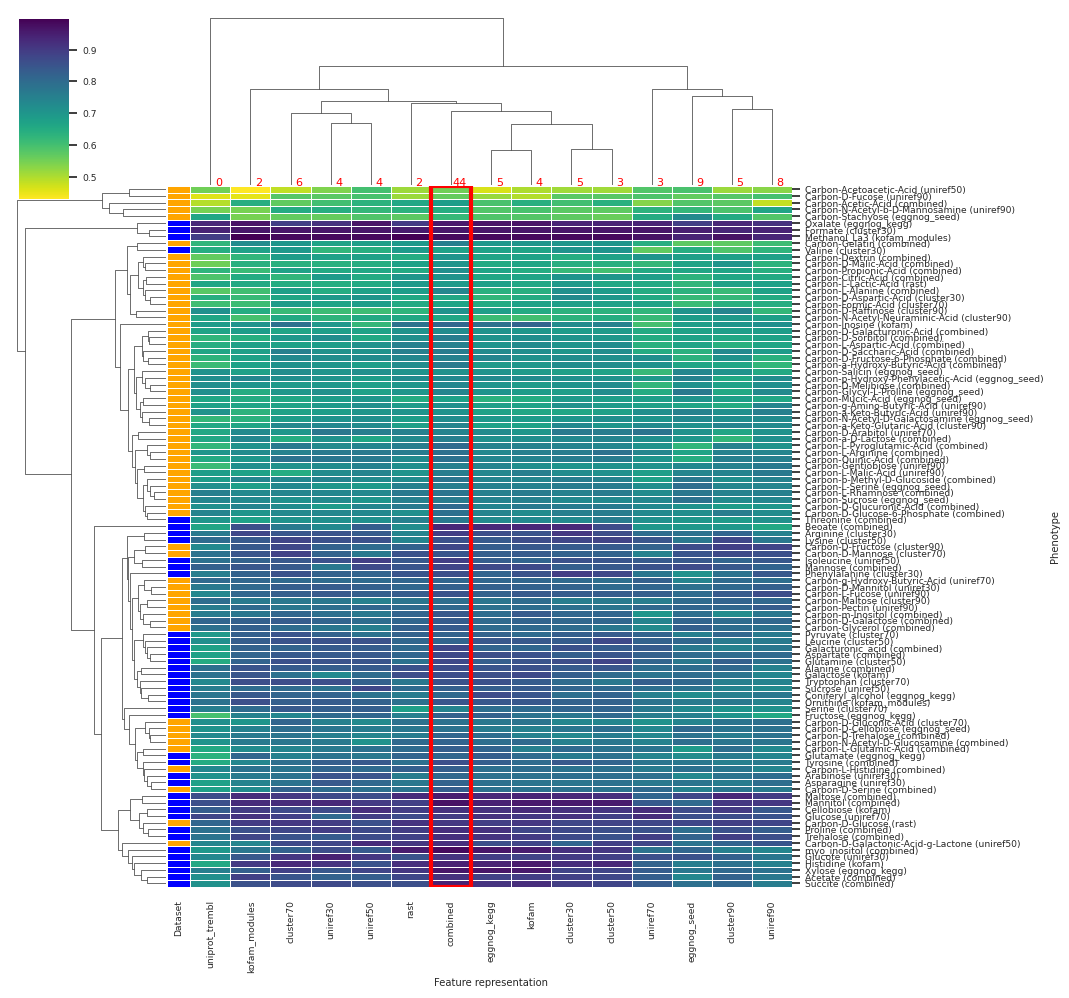

In [134]:
metric = "Balanced Accuracy"
plot_data = (
    cv_scores_df
    .loc[cv_scores_df["Preprocessing strategy"] == "Chi2(1000)", ["Dataset", "Feature representation", "Phenotype", metric]]
    .groupby(by=["Dataset", "Feature representation", "Phenotype"])
    .mean()
    .reset_index()
    .sort_values(by=metric, ascending=False)
    .pivot(index="Phenotype", columns="Feature representation", values=metric)
)
sns.set_theme(font_scale=0.6)
feature_rep_best_counts = plot_data.idxmax(axis=1).value_counts()
feature_rep_best_counts = feature_rep_best_counts.reindex(plot_data.columns, fill_value=0)
phenotype_best_feature_rep = plot_data.idxmax(axis=1)
color_map = make_colormap(cv_scores_df)
row_colors = pd.Series(plot_data.index.map(color_map), index=plot_data.index)
row_colors.name = "Dataset"
cmap = sns.color_palette("viridis", as_cmap=True).reversed()
g = sns.clustermap(plot_data,  linewidths=.5, cmap=cmap, yticklabels=1, row_colors=row_colors, )
ax = g.ax_heatmap
ax.add_patch(Rectangle((6, 0), 1, 104, fill=False, edgecolor='red', lw=3))
x_ticks = ax.get_xticks()
x_tick_labels = [(l.get_text(), feature_rep_best_counts[l.get_text()]) for l in ax.get_xticklabels()]
for i, (label, annot) in enumerate(x_tick_labels):
    ax.text(x_ticks[i] + 0.2, -0.5, f"{annot}", ha='center', va='center', fontsize=8, color='red')
y_tick_labels = [f"{l.get_text()} ({phenotype_best_feature_rep[l.get_text()]})" for l in ax.get_yticklabels()]
ax.set_yticklabels(y_tick_labels);

In [137]:
heatmap_rows = [t.get_text().split(" ")[0] for t in ax.get_yticklabels()]

In [108]:
def common_features(group):
    df = group.drop(["fold_num", "Dataset", "Feature representation", "Preprocessing strategy", "Phenotype"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return len(common_features) / m * 100

In [109]:
cv_features_df = read_csv_files(prediction_runs, "all_feat_cv_features_data.csv", reindex=True)

In [110]:
col_dict = {
    "name": "Phenotype",
    "category": "Dataset",
    "fold_num": "fold_num",
    "feature": "Feature representation",
    "run_id": "Preprocessing strategy"
}

cv_features_df = cv_features_df.rename(columns=col_dict)

In [111]:
cv_features_df["Dataset"] = cv_features_df["Dataset"].replace({"leaf_biolog": "AT leaf", "ch_biolog": "Literature"})
cv_features_df["Preprocessing strategy"] = cv_features_df["Preprocessing strategy"].replace(
    {
        "biolog": "Unprocessed",
        "biolog_chi2_1000": "Chi2(1000)",
        "biolog_f_1000": "F(1000)",
        "biolog_mutual_info_1000": "Mutual info(1000)",
        "biolog_nmf_200": "NMF(200)",
        "biolog_pca_200": "PCA(200)",
    }
)
cv_features_df

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_16,feat_17,feat_18,feat_19,feat_20,fold_num,Feature representation,Preprocessing strategy,Phenotype,Dataset
0,607_914,1152_3516,210_2137,967_3922,783_204,189_2758,662_4244,1218_2348,206_3640,1332_352,...,1341_2914,892_614,1250_1766,1342_79,77_2131,1,cluster30,Mutual info(1000),Oxalate,AT leaf
1,607_914,1152_3516,189_2758,1250_1766,967_3922,206_3640,783_204,261_2789,373_3497,1395_5686,...,373_3153,502_1172,1185_1097,1218_2348,219_5635,2,cluster30,Mutual info(1000),Oxalate,AT leaf
2,607_914,1152_3516,1250_1766,206_3640,967_3922,1332_352,189_2758,1218_2348,783_204,373_3497,...,662_4244,486_1354,575_3065,1395_5686,581_880,3,cluster30,Mutual info(1000),Oxalate,AT leaf
3,607_914,1152_3516,1218_2348,137_3641,1332_352,967_3922,783_204,1341_2914,654_4389,930_3124,...,624_2748,831_2517,748_2400,203_3442,575_3065,4,cluster30,Mutual info(1000),Oxalate,AT leaf
4,311_702,189_2758,206_3640,203_3442,373_3153,930_3124,494_1504,1395_5686,1152_3516,1067_2598,...,930_1133,1086_4448,8_5998,494_1367,630_1792,5,cluster30,Mutual info(1000),Oxalate,AT leaf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44195,382_538,K03200.1,905_2945,SSO:000002774,K02805,K01185,SSO:000004959,SSO:000013193,422_2164,K19048.1,...,SSO:000000428,SSO:000016637,K03304.1,K07039,K03200,1,combined,Chi2(1000),Carbon-a-D-Lactose,Literature
44196,382_538,SSO:000004959,K00996,K07814.1,K01007,K05350,SSO:000017946,K07258,K01286,K16568,...,SSO:000026099,SSO:000025235,1371_1343,K03200,SSO:000016966,2,combined,Chi2(1000),Carbon-a-D-Lactose,Literature
44197,K01286,K13653.1,K13653,102_616.1,K01046.1,K07258,382_538,UniRef50_A0A952UCL2,K03200.1,SSO:000021760,...,963_288,SSO:000011881,K16246,422_2164,491_3054,3,combined,Chi2(1000),Carbon-a-D-Lactose,Literature
44198,382_538,K00955,K00278,K17050,K01733,SSO:000021760,SSO:000010864,SSO:000026099,K00003,1081_1973,...,K03417,K13924,963_288,SSO:000022925,K12372,4,combined,Chi2(1000),Carbon-a-D-Lactose,Literature


/tmp/ipykernel_2398597/1043941184.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(common_features)


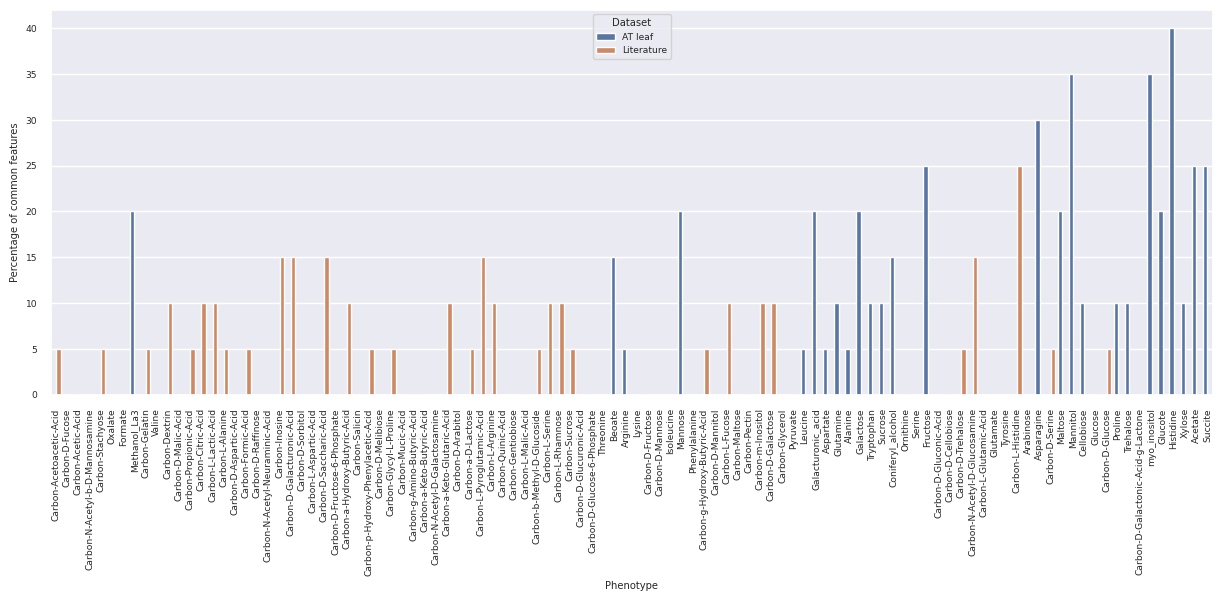

In [139]:
plot_data = (
    cv_features_df
    .loc[cv_features_df["Feature representation"] == "combined", :] # also assuming there is only on selection strategy
    .groupby(by=["Dataset", "Phenotype"])
    .apply(common_features)
    .reset_index()
)
plot_data.columns = ["Dataset", "Phenotype", "Percentage of common features"]
# plot_data["Percentage of common features"][plot_data["Percentage of common features"] > 0] = 1
plt.figure(figsize=(15, 5))
g = sns.barplot(data=plot_data, x="Phenotype", y="Percentage of common features", hue="Dataset", order=heatmap_rows)
# plt.ylim(0, 100)
plt.tick_params(axis='x', rotation=90, which="both");

## Histidine analysis

In [162]:
# Load histidine combined features
# Load histidine phenotype
# Get histidine top features and make heatmap

In [163]:
from trait_prediction.utils import read_generic_features

In [164]:
histdine_file = pathlib.Path("../../data/processed/biolog/features_combined/leaf/Histidine_features_combined.tsv")
histidine_features = read_generic_features(histdine_file, bool_conversion=True, dtype="uint8")
histidine_features

,1025_1128,927_411,607_11,616_3395,696_2361,1300_2061,1376_1391,625_4340,157_234,535_2951,...,UniRef70_UPI00111CEB0C,UniRef70_A0A2C9ELT7,UniRef70_A0A0Q4GI42,UniRef70_A0A6N6SUL3,UniRef70_A0A7U4LJA9,UniRef70_A0A4Q3PYE8,UniRef70_A0A6N9T966,UniRef70_A0A1Q3Z4F0,UniRef70_Q9L951,UniRef70_A0A0Q6BNW7
genomeID,,,,,,,,,,,,,,,,,,,,,
GCF_001421155.1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
GCF_001421165.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421245.1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
GCF_001421275.1,0,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_001421285.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_920984695.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_920984705.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_920984725.1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [165]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex

In [166]:
leaf_phenotypes = PhenotypeSet.read_data("../../data/processed/biolog/phenotypes/leaf_phenotypes.tsv")
index = PhenotypeIndex(name="Histidine", category="leaf_biolog")
histidine_phenotype = leaf_phenotypes[index]
histidine_phenotype.phenotype_data

genomeID
GCF_001421155.1    0
GCF_001421165.1    0
GCF_001421245.1    0
GCF_001421275.1    1
GCF_001421285.1    0
                  ..
GCF_920984695.1    0
GCF_920984705.1    0
GCF_920984725.1    0
GCF_920984735.1    0
GCF_942548115.1    0
Name: Histidine--leaf_biolog, Length: 202, dtype: uint8

In [175]:
phenotype_data = histidine_phenotype.phenotype_data

In [167]:
def get_common_feature_names(group):
    df = group.drop(["fold_num", "Dataset", "Feature representation", "Preprocessing strategy", "Phenotype"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return common_features

In [168]:
common_feature_data = (
    cv_features_df
    .loc[cv_features_df["Feature representation"] == "combined", :] # also assuming there is only on selection strategy
    .groupby(by=["Dataset", "Phenotype"])
    .apply(get_common_feature_names)
    .reset_index()
)
common_feature_data.columns = ["Dataset", "Phenotype", "Common features"]
common_feature_data

/tmp/ipykernel_2398597/949545549.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_common_feature_names)


,Dataset,Phenotype,Common features
0,AT leaf,Acetate,"{K19221.1, K19221, K01637.1, K01638.1, K01638}"
1,AT leaf,Alanine,{K00459}
2,AT leaf,Arabinose,{}
3,AT leaf,Arginine,{342_298.1}
4,AT leaf,Asparagine,"{K17686.1, K01744, 126_3045.1, K02010, K01744...."
...,...,...,...
99,Literature,Carbon-b-Methyl-D-Glucoside,{K07451}
100,Literature,Carbon-g-Amino-Butyric-Acid,{}
101,Literature,Carbon-g-Hydroxy-Butyric-Acid,{SSO:000000110}
102,Literature,Carbon-m-Inositol,"{K03335.1, K00010}"


In [172]:
top_histidine_features = list(common_feature_data[common_feature_data["Phenotype"] == "Histidine"]["Common features"].iloc[0])
top_histidine_features

['K07346',
 'K09975',
 'K01712',
 'K01468',
 'K01032',
 '1025_1128',
 'K09975.1',
 '1025_1128.1']

In [179]:
common_genomes = list(set(phenotype_data.index) & set(histidine_features.index))
features = histidine_features.loc[common_genomes, top_histidine_features]

In [180]:
features

,K07346,K09975,K01712,K01468,K01032,1025_1128,K09975.1,1025_1128.1
genomeID,,,,,,,,
GCF_001422345.1,0,0,0,0,0,0,0,0
GCF_001422495.1,0,0,1,1,0,0,0,0
GCF_001426045.1,0,0,0,0,0,0,0,0
GCF_001422185.1,1,0,0,0,0,0,0,0
GCF_001424145.1,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...
GCF_001421275.1,0,0,1,1,1,0,0,0
GCF_001421785.1,0,0,1,1,0,0,0,0
GCF_001422695.1,0,0,0,0,0,0,0,0


In [181]:
def make_colormap_phenotype(features, phenotype_data):
    phenotype_colormap = dict()
    dataset_colormap = {0: "red", 1: "green"}
    for r_id in features.index:
        phenotype_colormap[r_id] = dataset_colormap[phenotype_data[r_id]]
    return phenotype_colormap

In [194]:
from matplotlib.patches import Patch


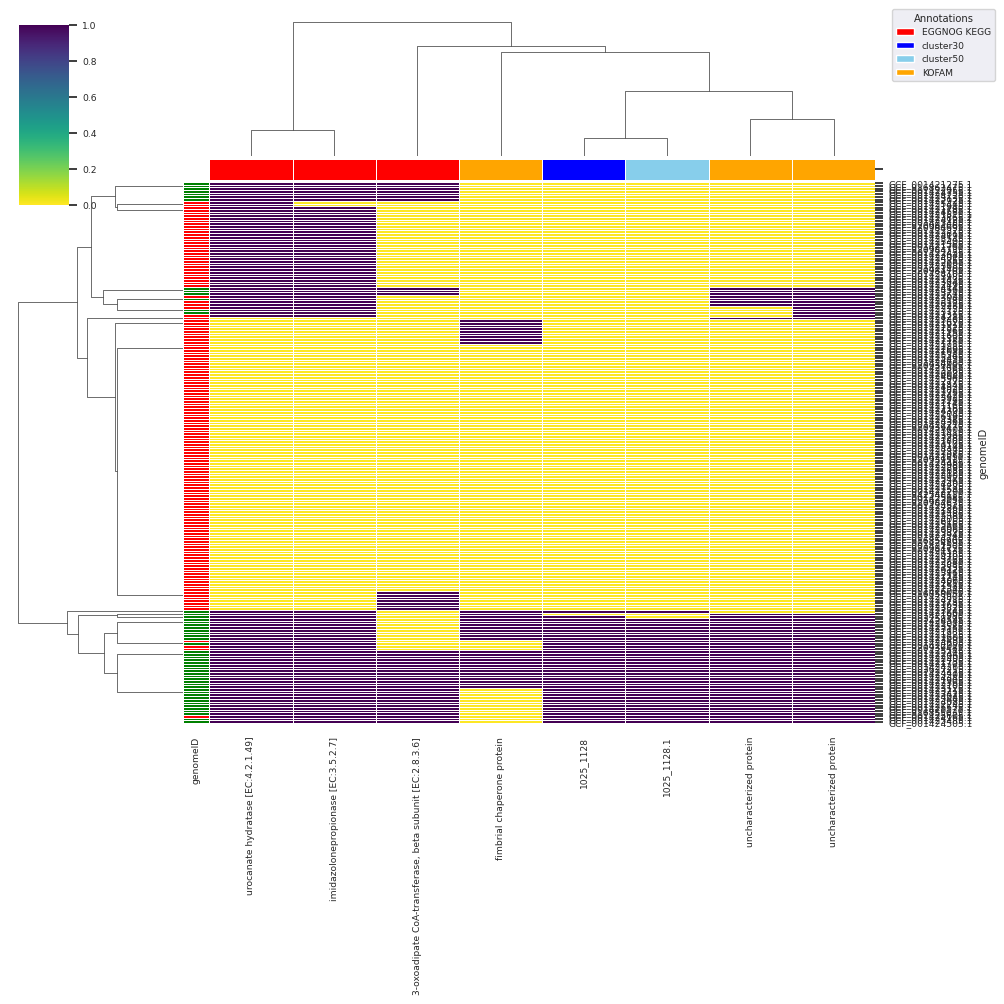

In [199]:
color_map = make_colormap_phenotype(features, phenotype_data)
row_colors = pd.Series(features.index.map(color_map), index=features.index)
col_map = {
    "K01712": "urocanate hydratase [EC:4.2.1.49]",
    "K01468": "imidazolonepropionase [EC:3.5.2.7]",
    "K01032": "3-oxoadipate CoA-transferase, beta subunit [EC:2.8.3.6]",
    "K07346": "fimbrial chaperone protein",
    "K09975": "uncharacterized protein",
    "K09975.1": "uncharacterized protein",
    }
col_categories = {
    "K01712": "EGGNOG KEGG",
    "K01468": "EGGNOG KEGG",
    "K01032": "EGGNOG KEGG",
    "K07346": "KOFAM",
    "K09975": "EGGNOG KEGG",
    "K09975.1": "KOFAM",
    "1025_1128": "cluster 30",
    "1025_1128.1": "cluster 50",
}
col_cat_color_map = {
    "EGGNOG KEGG": "red",
    "cluster30": "blue",
    "cluster50": "skyblue",
    "KOFAM": "orange",
}
col_color_map = {
    "K01712": "red",
    "K01468": "red",
    "K01032": "red",
    "K07346": "orange",
    "K09975": "red",
    "K09975.1": "orange",
    "1025_1128": "blue",
    "1025_1128.1": "skyblue",
}
features.columns = [col_map.get(c, c) for c in features.columns]
new_col_color_map = {col_map.get(k, k): v for k, v in col_color_map.items()}
col_colors = pd.Series(features.columns.map(new_col_color_map), index=features.columns)

g = sns.clustermap(features,  linewidths=.5, cmap=cmap, yticklabels=1, row_colors=row_colors, col_colors=col_colors)
# ax = g.ax_heatmap
# ax.add_patch(Rectangle((6, 0), 1, 104, fill=False, edgecolor='red', lw=3))

handles = [Patch(facecolor=col_cat_color_map[name]) for name in col_cat_color_map]
plt.legend(handles, col_cat_color_map, title='Annotations',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')